<a href="https://colab.research.google.com/github/dinaOuahbi/Some_MLs-with-python/blob/main/surv_ana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#!pip install scikit-survival

In [343]:
'''
scikit-survival: 
  - survival analysis 
  - link cov - pfs/os
  - données partielement observées (censurées)
  - patient censuré | patient non censuré | event = 1

install via anaconda
install derniere version via un lien GIT
à certaines dependances

type de pb de regression avec torsion
les etats d'un patients : 
  - PDV ==> censuré
  - have the event
  - dropped out from the study ==> censuré
  - didn't get the event ==> censuré

analyse de survie predit deux fonctions differentes: 
- S(t) : proba de survie au dela de t
- h(t) : proba que l'event se produit dans un delta-t
- H(t) : le hasard cumulé = l'integrale sur l'intervalle [0;t[ de h(t)

ces fonctions estime qu'une fonction de risque de base existe et qui s'appel le h0(t)

le model de risque proportiennel (coxPH)  : va estimé la S(t) et H(t) en presence de cov supplementaires. le risque de base existe et les cov ne vont modifier la survie
que proportionnelement ===> ratio H(t) p1 / H(t) p2 = constante



'''

"\nscikit-survival: \n  - survival analysis \n  - link cov - pfs/os\n  - données partielement observées (censurées)\n  - patient censuré | patient non censuré | event = 1\n\ninstall via anaconda\ninstall derniere version via un lien GIT\nà certaines dependances\n\ntype de pb de regression avec torsion\nles etats d'un patients : \n  - PDV ==> censuré\n  - have the event\n  - dropped out from the study ==> censuré\n  - didn't get the event ==> censuré\n\nanalyse de survie predit deux fonctions differentes: \n- S(t) : proba de survie au dela de t\n- h(t) : proba que l'event se produit dans un delta-t\n- H(t) : le hasard cumulé = l'integrale sur l'intervalle [0;t[ de h(t)\n\nces fonctions estime qu'une fonction de risque de base existe et qui s'appel le h0(t)\n\nle model de risque proportiennel (coxPH)  : va estimé la S(t) et H(t) en presence de cov supplementaires. le risque de base existe et les cov ne vont modifier la survie\nque proportionnelement ===> ratio H(t) p1 / H(t) p2 = constan

In [400]:
import pandas as pd
import numpy as np
from sksurv.datasets import load_veterans_lung_cancer
%matplotlib inline
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival

In [345]:
df = pd.read_csv('/content/surg_rad_merge.csv', index_col = 'ID')
df.head()

,AEG,KPS2,TYPECHIR2,EPILEPSIE,KPS1,CHIMIO2,DATEDECES,RADIO2,BIOPSIE1,DEFICIT,...,FINCHIMIO2,DATERECIDIVE,CTC2,REINS,GROUP,age_interval,PFS1,PFS2,OS1,OS2
ID,,,,,,,,,,,,,,,,,,,,,
KASSAR_KHEIRA,OUI,60.0,EST,OUI,90.0,MUPHORAN,2019-08-22,NaN,NON,"HLH HNG DEFICIT MOTEUR, tb phasiques",...,2019-08-09,2018-06-25,160.0,NON,surg,>= 65,164.0,410.0,587.0,423.0
CARMINATI_MARTINE,NaN,80.0,EST,OUI,100.0,AVASTIN MUPHORAN,2019-11-20,NaN,NON,PHASIQUE,...,2019-10-14,2019-04-24,80.0,NON,surg,>= 54 & < 65,421.0,173.0,631.0,210.0
PAULIN_LAETITIA,OUI,90.0,EST,NaN,90.0,MUPHORAN AVASTIN puis Carboplatine,2017-10-01,NaN,NON,Hemiparésie droite,...,2017-08-01,2017-03-07,120.0,NON,surg,< 54,435.0,147.0,643.0,208.0
PRIEUR_VALERIE,NaN,90.0,ET,OUI,100.0,MUPHORAN AVASTIN,2018-08-16,NaN,NON,NON,...,2018-04-10,2017-11-15,200.0,NON,surg,< 54,235.0,146.0,509.0,274.0
MANZONI_FABRISIO,OUI,70.0,EST,OUI,100.0,MUPHORAN AVASTIN puis CARBOPLATINE AVASTIN,2018-02-05,NaN,NON,Hémiparésie gauche,...,2017-11-20,2017-03-10,80.0,NON,surg,>= 65,534.0,255.0,866.0,332.0


In [346]:
def get_delta_time(start, end):
  df[start] = pd.to_datetime(df[start], yearfirst=True)
  df[end] = pd.to_datetime(df[end], yearfirst=True)
  d = df[end] - df[start]
  d = pd.Series(d).fillna(pd.Timedelta(days=0)).tolist()
  return [i.days for i in d]

In [347]:
def generate_status(time_l):
  stat = list()
  for i in time_l:
    if i==0:
      stat.append(False)
    else:
      stat.append(True)
  return stat

In [348]:
df['DATEDECES']['REBOUX_DANIEL'] = df['FINCHIMIO2']['REBOUX_DANIEL']
df['DATEDECES']['REBOUILLAT_PASCAL'] = df['DATECHIMIO2']['REBOUILLAT_PASCAL']

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [349]:
df['PFS1'] = get_delta_time('DATECHIR1', 'DATERECIDIVE')
df['PROG1'] = generate_status(get_delta_time('DATECHIR1', 'DATERECIDIVE'))

df['PFS2'] = get_delta_time('DATERECIDIVE', 'FINCHIMIO2')
df['PROG2'] = generate_status(get_delta_time('DATERECIDIVE', 'FINCHIMIO2'))

df['OS1'] = get_delta_time('DATECHIR1','DATEDECES')
df['DCD1'] = generate_status(get_delta_time('DATECHIR1','DATEDECES'))

df['OS2'] = get_delta_time('DATERECIDIVE','DATEDECES')
df['DCD2'] = generate_status(get_delta_time('DATERECIDIVE','DATEDECES'))

In [350]:
data_x = df[['KPS2','TYPECHIR2','KPS1','CHIMIO2','BIOPSIE1','DEFICIT','TYPERADIO2', 'LOC2', 'AGE','CŒUR','TABAC','TYPECHIR1','LOC1',
       'IMMUNODEP', 'MGMT', 'IDH', 'COTE','COMPLICATION1', 'SEXE', 'DIABETE','CTC2','REINS','age_interval', 'GROUP']]

In [351]:
#KPS1 / KPS2
def replace_KPS(col, dich):
  temp = list()
  for i in data_x[col]:
    if i>dich:
      temp.append(1)
    elif i<=dich:
      temp.append(0)
    else:
      temp.append(i)
  data_x[col] = temp

replace_KPS('KPS1', 70)
replace_KPS('KPS2', 70)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()


In [352]:
#CTC2 / https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5167467/
replace_KPS('CTC2',np.median(data_x['CTC2'].dropna()))

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()


In [353]:
# TYPECHIR2
data_x['TYPECHIR2'].replace({'NON':'biopsy'}, inplace=True)
data_x.drop(data_x[data_x['TYPECHIR2'] =='Radionecrose'].index[0], axis=0, inplace=True)


/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)
/usr/local/lib/python3.7/dist-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [382]:
df.drop(df[df['TYPECHIR2'] =='Radionecrose'].index[0], axis=0, inplace=True)

In [354]:
#TYPERADIO2
data_x.drop('TYPERADIO2', axis=1, inplace=True) #same as GROUP

/usr/local/lib/python3.7/dist-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [355]:
#CŒUR
data_x['CŒUR'].replace({'ACFA':'OUI',
                        'hamartochondrome pulmonaire 2009':'OUI',
                        'AVC':'OUI'},
                       inplace=True)

/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [356]:
#TABAC
data_x['TABAC'] = data_x['TABAC'].replace({'BPCO 72 PA':'OUI'})

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [357]:
#TYPECHIR1
data_x['TYPECHIR1'].replace({'NON':'biopsy'},inplace=True)

/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [358]:
#IMMUNODEP
for i in data_x['IMMUNODEP']:
  if i not in ('OUI','NON'):
    data_x['IMMUNODEP'].replace({i:'OUI'}, inplace=True)

/usr/local/lib/python3.7/dist-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [359]:
#IDH
data_x['IDH'] = data_x['IDH'].replace({'POSITIF':'POS'})

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [360]:
#COMPLICATION1
data_x['COMPLICATION1'] = data_x['COMPLICATION1'].replace({'OUI, Méningite post op':'OUI'})

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [361]:
#REINS
data_x['REINS'] = data_x['REINS'].replace({'Nephrectomie':'OUI'})

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [362]:
dic = dict()
for col in data_x.columns:
  dic_bis = dict()
  for i in range(len(data_x[col].value_counts().index)):
    dic_bis[data_x[col].value_counts().index[i]] = data_x[col].value_counts().values[i]
  dic[col] = dic_bis
val_counts = pd.DataFrame(dic.items(), columns=['col','val'])

In [454]:
val_counts

,col,val
0,KPS2,"{0.0: 32, 1.0: 20}"
1,TYPECHIR2,"{'EST': 26, 'biopsy': 20, 'ET': 6}"
2,KPS1,"{1.0: 50, 0.0: 1}"
3,CHIMIO2,"{'MUPHORAN AVASTIN': 16, 'AVASTIN MUPHORAN': 1..."
4,BIOPSIE1,"{'NON': 47, 'OUI': 5}"
5,DEFICIT,"{'NON': 10, 'Aphasie': 4, 'Parésie gauche': 3,..."
6,LOC2,"{'T': 11, 'F': 8, 'FD': 4, 'FG': 4, 'O': 3, 'P..."
7,AGE,"{69.0: 6, 61.0: 4, 56.0: 4, 62.0: 3, 65.0: 3, ..."
8,CŒUR,"{'NON': 47, 'OUI': 6}"
9,TABAC,"{'NON': 40, 'OUI': 13}"


In [363]:
#delete some patient (radionecrose)
drop_patient = ['MARTIN_JEAN PIERRE','GAGNARD_MARIE FRANCE']
data_x.drop(drop_patient, axis=0, inplace=True)

/usr/local/lib/python3.7/dist-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [377]:
df.drop(drop_patient, axis=0, inplace=True)

In [364]:
data_y = df[['PROG1','PFS1']].to_records(index=False)

In [366]:
data_x.reset_index(drop=True, inplace=True)

**SURVIVAL FUNCTION **

In [368]:
def generate_km(PROG, PFS):
  data_y = df[[PROG,PFS]].to_records(index=False)
  time, survival_prob = kaplan_meier_estimator(data_y[PROG], data_y[PFS])
  plt.step(time, survival_prob, where="post", label=f'{PFS}')
  plt.ylabel("Probability of survival $\hat{S}(t)$")
  plt.xlabel("time $t$ (m)")
  plt.legend(loc="best")

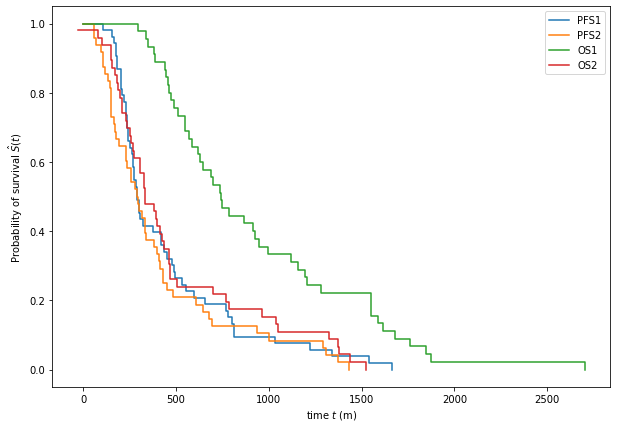

In [369]:
plt.figure(figsize=(10,7))
generate_km('PROG1', 'PFS1')
generate_km('PROG2', 'PFS2')
generate_km('DCD1', 'OS1')
generate_km('DCD2', 'OS2')

# os2 ????

In [387]:
def surv_diff(col, PFS, PROG, c1, c2):
  data_y = df[[PROG,PFS]].to_records(index=False)
  for value in (c1,c2):
    mask = data_x[col] == value
    time_treatment, survival_prob_treatment = kaplan_meier_estimator(
        data_y[PROG][mask],
        data_y[PFS][mask])
    plt.step(time_treatment, survival_prob_treatment, where="post",
             label=value)
  plt.ylabel("Probability of survival $\hat{S}(t)$")
  plt.xlabel("time $t$ (m)")
  plt.legend(loc="best")


In [ ]:
from lifelines.statistics import logrank_test
def log_rank(col, PFS, PROG, c1, c2):
  data_y = df[[PROG,PFS]].to_records(index=False)
  T = data_y[PFS][data_x[col] == c1]
  T1 = data_y[PFS][data_x[col] == c2]
  E = data_y[PROG][data_x[col] == c1]
  E1 = data_y[PROG][data_x[col] == c2]
  res = logrank_test(T, T1, event_observed_A=E, event_observed_B=E1)
  return res

Text(0.5, 1.0, 'OS2| p_val = 0.15028')

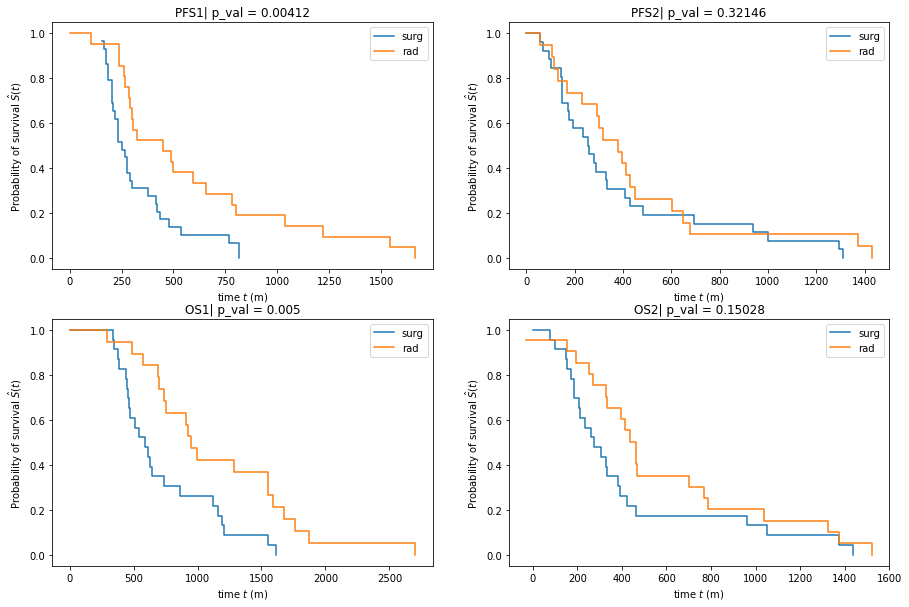

In [425]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
surv_diff('GROUP', 'PFS1', 'PROG1', 'surg', 'rad')
res = log_rank('GROUP', 'PFS1', 'PROG1', 'surg', 'rad')
plt.title(f'PFS1| p_val = {round(res.p_value, 5)}')

plt.subplot(2,2,2)
surv_diff('GROUP', 'PFS2', 'PROG2', 'surg', 'rad')
res = log_rank('GROUP', 'PFS2', 'PROG2', 'surg', 'rad')
plt.title(f'PFS2| p_val = {round(res.p_value, 5)}')

plt.subplot(2,2,3)
surv_diff('GROUP', 'OS1', 'DCD1', 'surg', 'rad')
res = log_rank('GROUP', 'OS1', 'DCD1', 'surg', 'rad')
plt.title(f'OS1| p_val = {round(res.p_value, 5)}')

plt.subplot(2,2,4)
surv_diff('GROUP', 'OS2', 'DCD2', 'surg', 'rad')
res = log_rank('GROUP', 'OS2', 'DCD2', 'surg', 'rad')
plt.title(f'OS2| p_val = {round(res.p_value, 5)}')

In [453]:
val_counts

,col,val
0,KPS2,"{0.0: 32, 1.0: 20}"
1,TYPECHIR2,"{'EST': 26, 'biopsy': 20, 'ET': 6}"
2,KPS1,"{1.0: 50, 0.0: 1}"
3,CHIMIO2,"{'MUPHORAN AVASTIN': 16, 'AVASTIN MUPHORAN': 1..."
4,BIOPSIE1,"{'NON': 47, 'OUI': 5}"
5,DEFICIT,"{'NON': 10, 'Aphasie': 4, 'Parésie gauche': 3,..."
6,LOC2,"{'T': 11, 'F': 8, 'FD': 4, 'FG': 4, 'O': 3, 'P..."
7,AGE,"{69.0: 6, 61.0: 4, 56.0: 4, 62.0: 3, 65.0: 3, ..."
8,CŒUR,"{'NON': 47, 'OUI': 6}"
9,TABAC,"{'NON': 40, 'OUI': 13}"


**MODELE DE SURVIE MULTIVARIE**

In [433]:
from sksurv.preprocessing import OneHotEncoder

In [436]:
def convert_types(df,cat_names):
      dtypes = {cat:'category' for cat in cat_names}
      df = df.astype(dtypes)
      return df

In [439]:
cat_names = data_x.select_dtypes('object').columns
my_df = convert_types(data_x.select_dtypes('object'),cat_names)

In [447]:
data_x_numeric = OneHotEncoder().fit_transform(my_df.dropna())
data_x_numeric.head()

,TYPECHIR2=ET,TYPECHIR2=biopsy,CHIMIO2=AVASTIN LOMUSTINE,CHIMIO2=AVASTIN LOMUSTINE MUPHORAN,CHIMIO2=AVASTIN MUPHORAN,CHIMIO2=AVASTIN OLAPARIB,CHIMIO2=AVASTIN puis MUPHORAN,CHIMIO2=AVASTIN puis REGORAFENIB,CHIMIO2=BELUSTINE,CHIMIO2=BELUSTINE AVASTIN,...,COTE=D + G,COTE=FP,COTE=G,COMPLICATION1=OUI,SEXE=H,DIABETE=OUI,REINS=OUI,age_interval=>= 54 & < 65,age_interval=>= 65,GROUP=surg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [448]:
data_x_numeric.shape

(34, 107)

In [452]:
from sksurv.linear_model import CoxPHSurvivalAnalysis
estimator = CoxPHSurvivalAnalysis()